In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [ ]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params_v5
from src.MultiVariateForecaster import MultiVariateForecaster
from src.visualization import plot_forecast_with_train
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    for i in range(0, len(target_cols)):
        col = target_cols[i]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        if i != 0:
            neighbor_col = target_cols[i - 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_up']
        if i != len(target_cols) - 1:
            neighbor_col = target_cols[i + 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_down']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))       
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../xgboost/models/xgb_v7'
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_anomaly']

In [7]:
study = search_params_v5(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=15)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-24 15:39:07,764] A new study created in memory with name: no-name-c0bd237f-4609-4cee-a9f1-991d8cf1f53b
[I 2026-05-24 15:39:39,257] Trial 0 finished with value: 0.5410426712286981 and parameters: {'n_estimators': 686, 'learning_rate': 0.004165612201056567, 'max_depth': 7, 'subsample': 0.5633340313092009, 'colsample_bytree': 0.4539665954483548, 'colsample_bylevel': 0.786634497026278, 'colsample_bynode': 0.8607070693259473, 'reg_alpha': 7.216676068983717, 'reg_lambda': 0.006502655558818266, 'gamma': 0.00013371090604963185, 'min_child_weight': 12, 'max_delta_step': 19, 'lags_48-1 (0)': 1, 'neighbor_lags_48-1 (0)_down': 2, 'lags_48-1 (0,5)': 2, 'neighbor_lags_48-1 (0,5)_up': 3, 'neighbor_lags_48-1 (0,5)_down': 1, 'lags_48-1 (1)': 3, 'neighbor_lags_48-1 (1)_up': 3, 'neighbor_lags_48-1 (1)_down': 1, 'lags_48-1 (1,5)': 5, 'neighbor_lags_48-1 (1,5)_up': 1, 'neighbor_lags_48-1 (1,5)_down': 3, 'lags_48-1 (2)': 3, 'neighbor_lags_48-1 (2)_up': 1, 'neighbor_lags_48-1 (2)_down': 1, 'lags_4

Лучшие параметры = {'n_estimators': 581, 'learning_rate': 0.013751423346933623, 'max_depth': 7, 'subsample': 0.439970153878579, 'colsample_bytree': 0.764978084711414, 'colsample_bylevel': 0.8908863948269177, 'colsample_bynode': 0.6760016349739831, 'reg_alpha': 0.000132263467240764, 'reg_lambda': 0.0002513021388942465, 'gamma': 0.00020858603550430132, 'min_child_weight': 13, 'max_delta_step': 12, 'lags_48-1 (0)': 1, 'neighbor_lags_48-1 (0)_down': 1, 'lags_48-1 (0,5)': 5, 'neighbor_lags_48-1 (0,5)_up': 3, 'neighbor_lags_48-1 (0,5)_down': 3, 'lags_48-1 (1)': 2, 'neighbor_lags_48-1 (1)_up': 2, 'neighbor_lags_48-1 (1)_down': 3, 'lags_48-1 (1,5)': 4, 'neighbor_lags_48-1 (1,5)_up': 2, 'neighbor_lags_48-1 (1,5)_down': 2, 'lags_48-1 (2)': 1, 'neighbor_lags_48-1 (2)_up': 3, 'neighbor_lags_48-1 (2)_down': 2, 'lags_48-1 (2,5)': 3, 'neighbor_lags_48-1 (2,5)_up': 1, 'neighbor_lags_48-1 (2,5)_down': 3, 'lags_48-1 (3)': 2, 'neighbor_lags_48-1 (3)_up': 2, 'neighbor_lags_48-1 (3)_down': 3, 'lags_48-1 (3

In [8]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v7']

48-1 (0)
RMSE на тесте = 2.9290064524055373


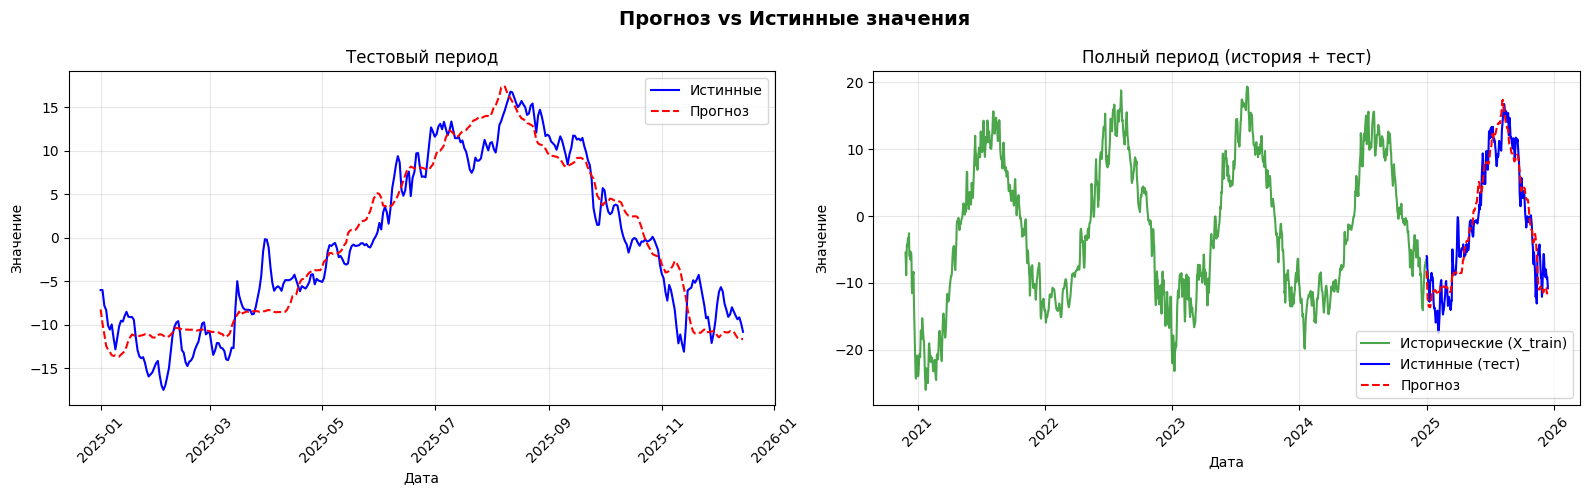

            feature  importance
0    48-1 (0)_lag_1    0.226478
3         Месяц_cos    0.202375
1  48-1 (0,5)_lag_1    0.166686
6        is_anomaly    0.162575
5   day_of_year_cos    0.147572
2         Месяц_sin    0.054293
4   day_of_year_sin    0.040021
48-1 (0,5)
RMSE на тесте = 1.6889391734483334


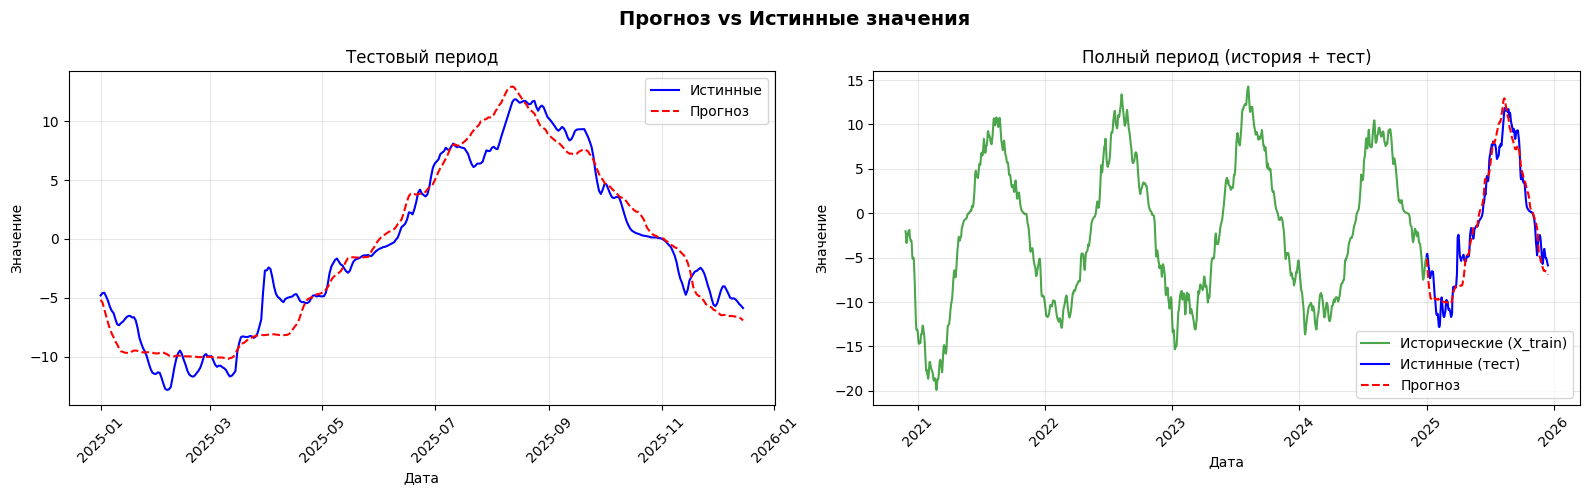

             feature  importance
4   48-1 (0,5)_lag_2    0.273882
3   48-1 (0,5)_lag_1    0.230327
6   48-1 (0,5)_lag_4    0.172527
5   48-1 (0,5)_lag_3    0.158969
7   48-1 (0,5)_lag_5    0.110885
2     48-1 (0)_lag_3    0.020801
1     48-1 (0)_lag_2    0.013351
0     48-1 (0)_lag_1    0.011502
8     48-1 (1)_lag_1    0.002609
9     48-1 (1)_lag_2    0.001352
11         Месяц_sin    0.000811
14   day_of_year_cos    0.000729
13   day_of_year_sin    0.000704
10    48-1 (1)_lag_3    0.000682
12         Месяц_cos    0.000436
15        is_anomaly    0.000434
48-1 (1)
RMSE на тесте = 1.1277992878014433


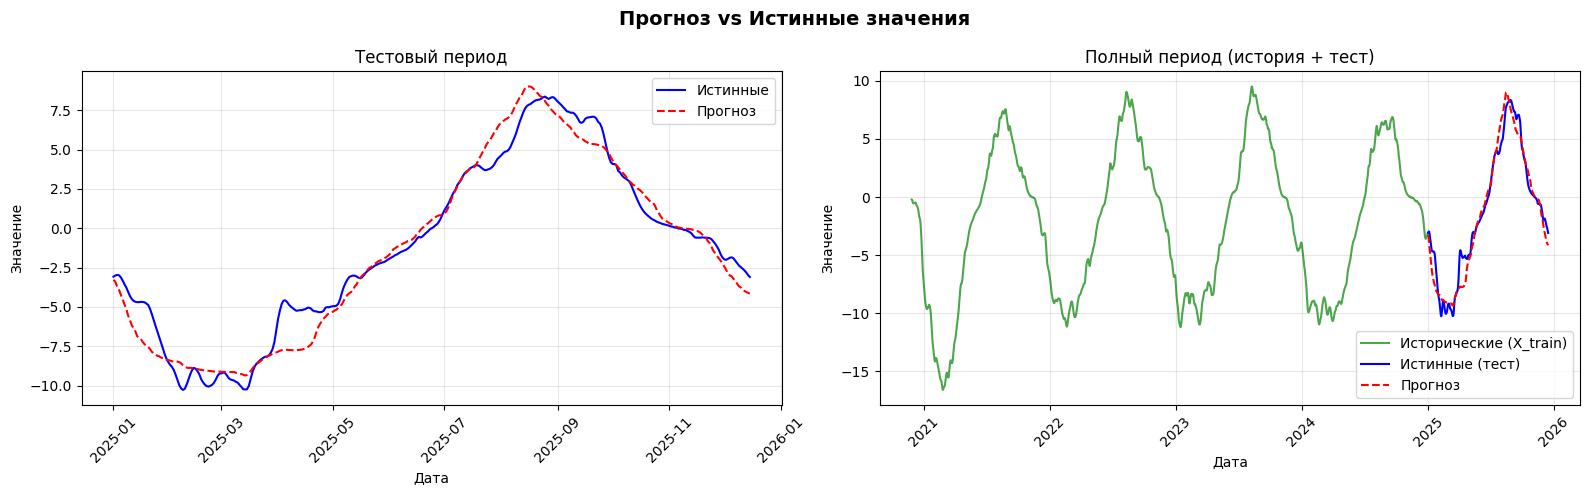

             feature  importance
3     48-1 (1)_lag_2    0.353689
2     48-1 (1)_lag_1    0.204127
4   48-1 (1,5)_lag_1    0.199622
1   48-1 (0,5)_lag_2    0.126600
0   48-1 (0,5)_lag_1    0.044040
7          Месяц_sin    0.028874
5   48-1 (1,5)_lag_2    0.020972
9    day_of_year_sin    0.006205
6   48-1 (1,5)_lag_3    0.006017
10   day_of_year_cos    0.005584
8          Месяц_cos    0.004208
11        is_anomaly    0.000063
48-1 (1,5)
RMSE на тесте = 0.8061538152690204


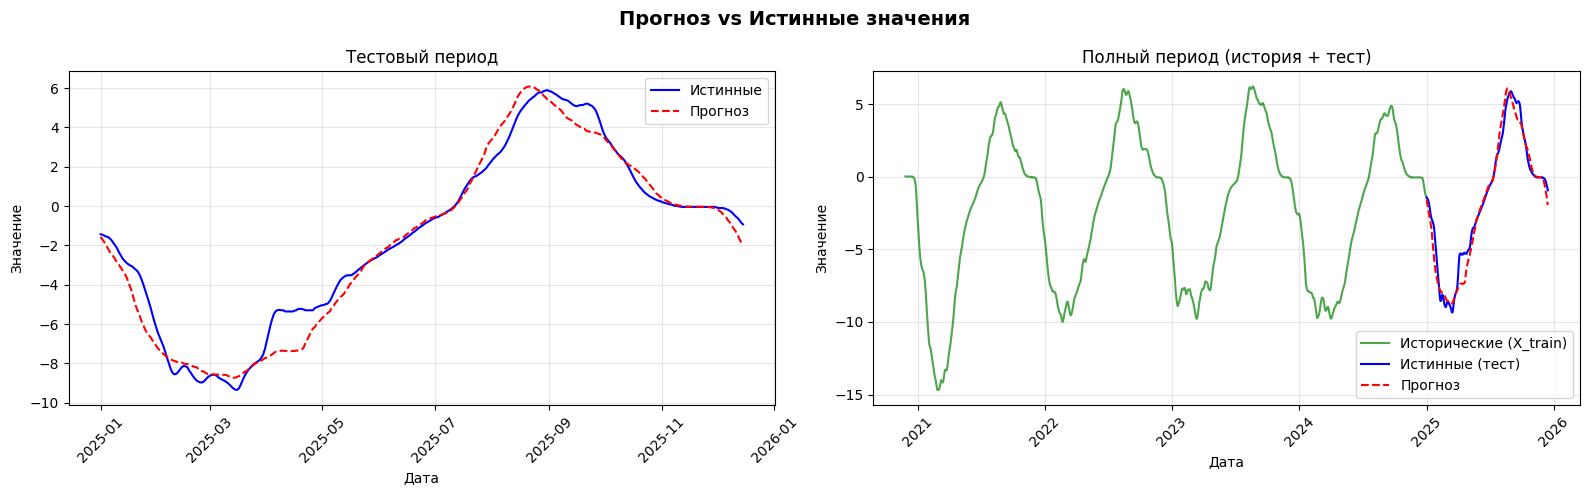

             feature  importance
3   48-1 (1,5)_lag_2    0.277071
2   48-1 (1,5)_lag_1    0.248926
4   48-1 (1,5)_lag_3    0.179753
5   48-1 (1,5)_lag_4    0.132048
1     48-1 (1)_lag_2    0.083611
0     48-1 (1)_lag_1    0.037257
6     48-1 (2)_lag_1    0.030649
10   day_of_year_sin    0.003682
11   day_of_year_cos    0.002628
9          Месяц_cos    0.002568
7     48-1 (2)_lag_2    0.001492
8          Месяц_sin    0.000274
12        is_anomaly    0.000041
48-1 (2)
RMSE на тесте = 0.6111941374703556


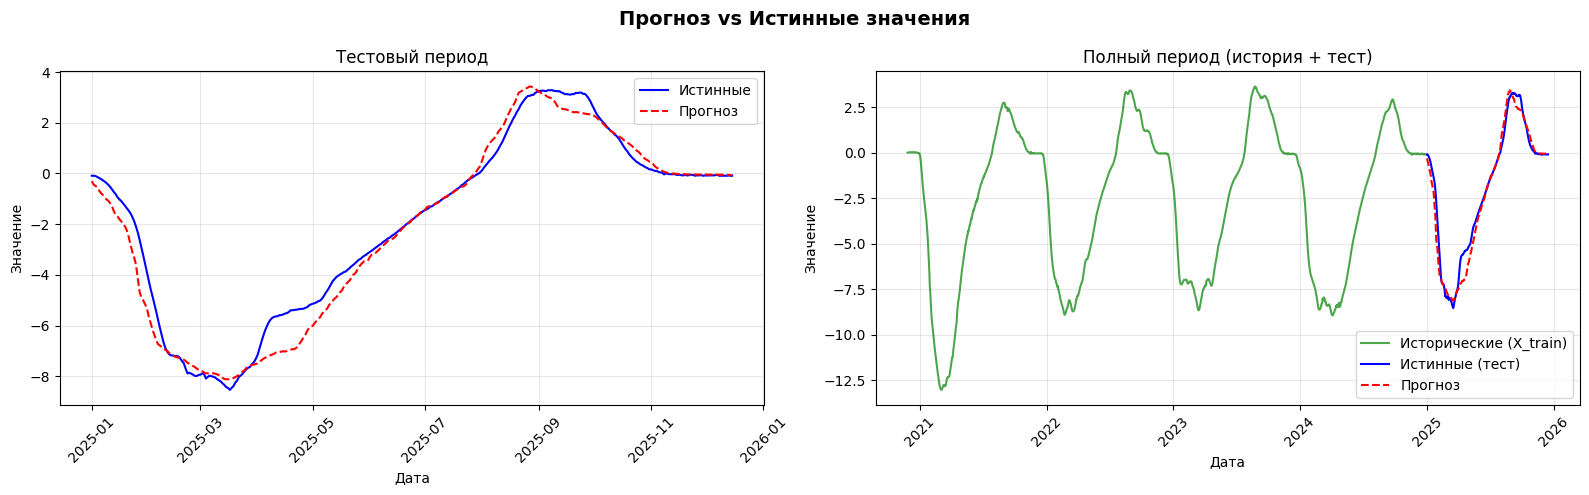

             feature  importance
2   48-1 (1,5)_lag_3    0.285802
4   48-1 (2,5)_lag_1    0.193786
3     48-1 (2)_lag_1    0.186091
5   48-1 (2,5)_lag_2    0.090997
1   48-1 (1,5)_lag_2    0.085361
6          Месяц_sin    0.064204
8    day_of_year_sin    0.039289
0   48-1 (1,5)_lag_1    0.032700
9    day_of_year_cos    0.009733
7          Месяц_cos    0.007545
10        is_anomaly    0.004493
48-1 (2,5)
RMSE на тесте = 0.5941773465016573


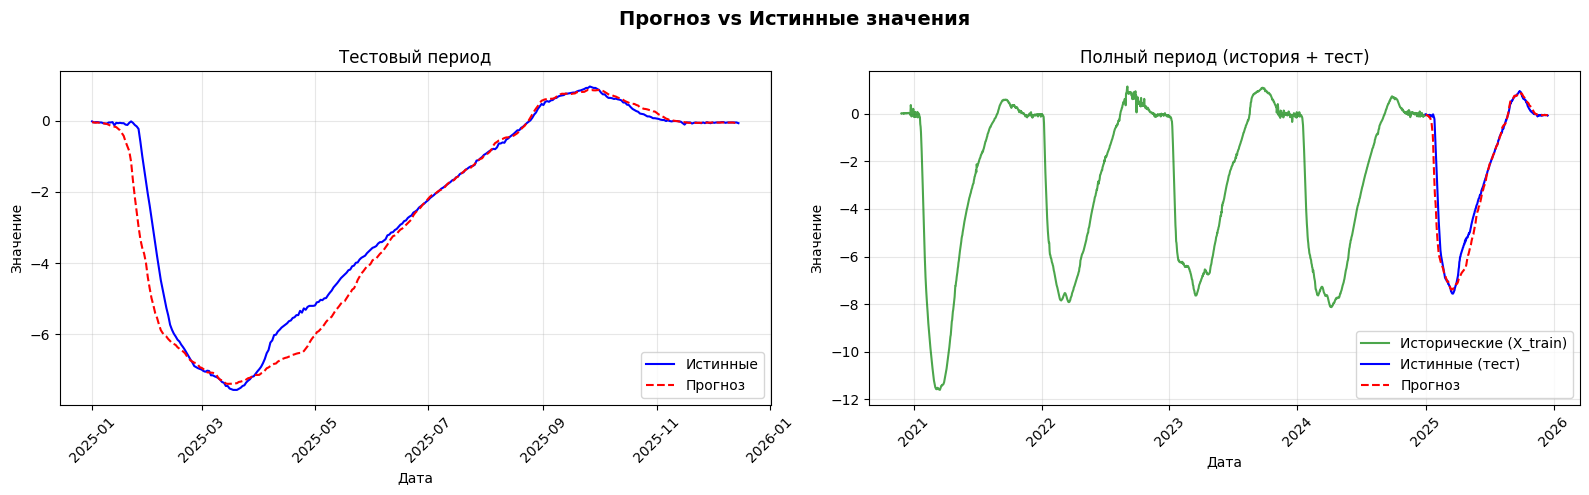

             feature  importance
2   48-1 (2,5)_lag_2    0.269004
1   48-1 (2,5)_lag_1    0.252621
4     48-1 (3)_lag_1    0.221378
3   48-1 (2,5)_lag_3    0.112526
6     48-1 (3)_lag_3    0.048849
0     48-1 (2)_lag_1    0.043281
7          Месяц_sin    0.018388
5     48-1 (3)_lag_2    0.014374
9    day_of_year_sin    0.011135
8          Месяц_cos    0.005023
10   day_of_year_cos    0.002236
11        is_anomaly    0.001186
48-1 (3)
RMSE на тесте = 0.5229750454792523


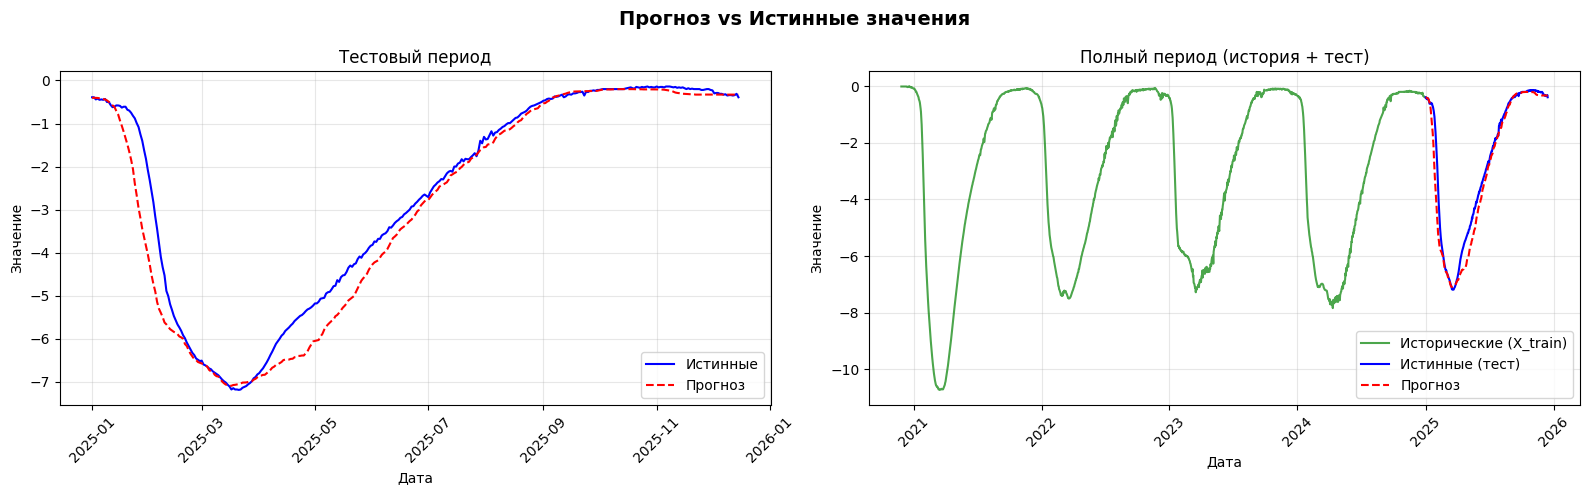

             feature  importance
1   48-1 (2,5)_lag_2    0.316647
2     48-1 (3)_lag_1    0.183823
4   48-1 (3,5)_lag_1    0.181786
0   48-1 (2,5)_lag_1    0.147689
5   48-1 (3,5)_lag_2    0.086444
3     48-1 (3)_lag_2    0.061684
6   48-1 (3,5)_lag_3    0.020646
10   day_of_year_cos    0.000376
9    day_of_year_sin    0.000316
11        is_anomaly    0.000231
8          Месяц_cos    0.000216
7          Месяц_sin    0.000142
48-1 (3,5)
RMSE на тесте = 0.5432612666517544


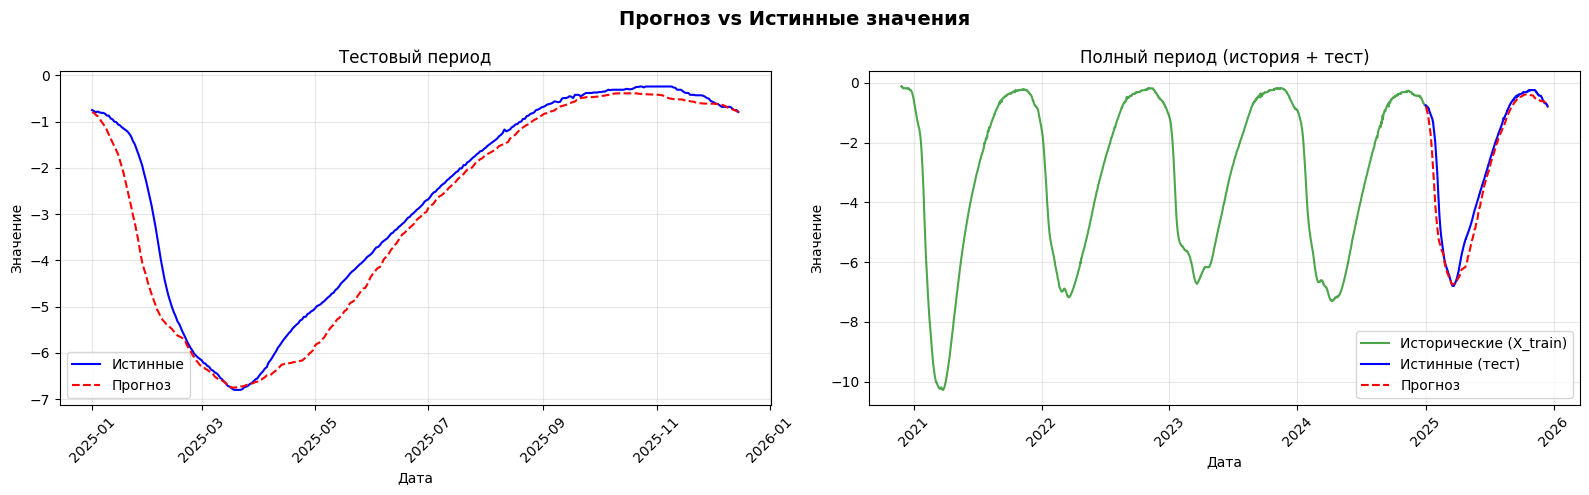

             feature  importance
6     48-1 (4)_lag_2    0.327843
0     48-1 (3)_lag_1    0.194627
1   48-1 (3,5)_lag_1    0.143521
5     48-1 (4)_lag_1    0.139574
3   48-1 (3,5)_lag_3    0.108193
2   48-1 (3,5)_lag_2    0.070050
4   48-1 (3,5)_lag_4    0.013579
11        is_anomaly    0.000817
7          Месяц_sin    0.000665
9    day_of_year_sin    0.000408
10   day_of_year_cos    0.000406
8          Месяц_cos    0.000317
48-1 (4)
RMSE на тесте = 0.5015118686867988


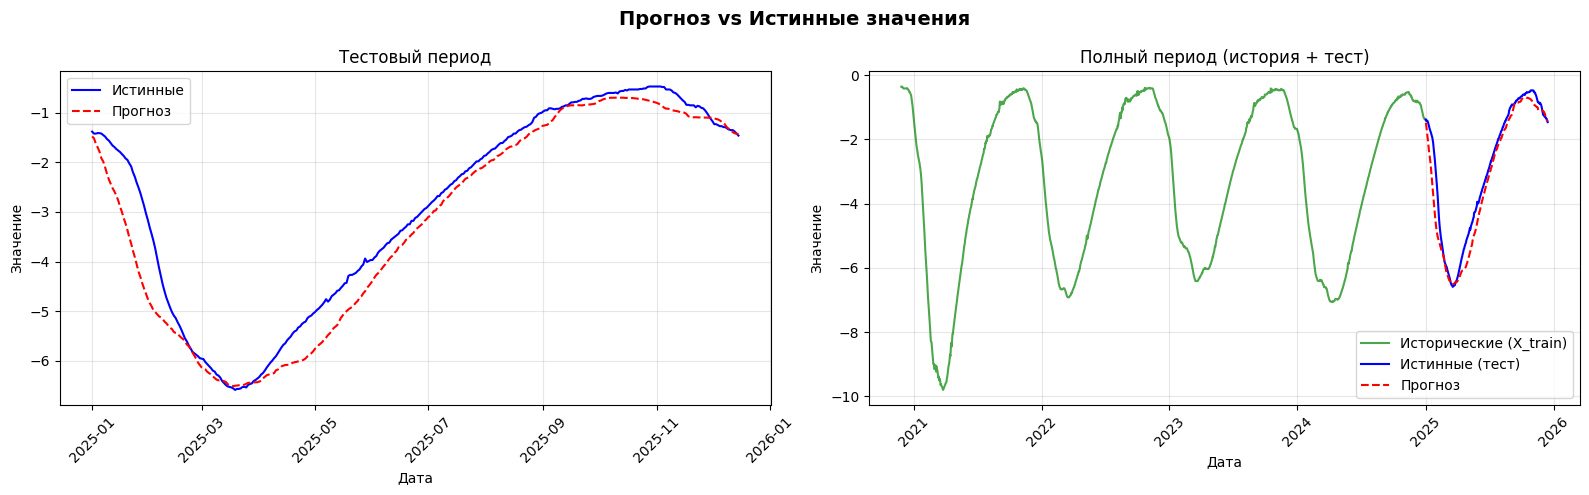

             feature  importance
3     48-1 (4)_lag_2    0.229489
5   48-1 (4,5)_lag_2    0.223303
4   48-1 (4,5)_lag_1    0.163789
2     48-1 (4)_lag_1    0.142211
0   48-1 (3,5)_lag_1    0.123914
1   48-1 (3,5)_lag_2    0.055387
8    day_of_year_sin    0.035022
6          Месяц_sin    0.022351
10        is_anomaly    0.003455
7          Месяц_cos    0.000659
9    day_of_year_cos    0.000418
48-1 (4,5)
RMSE на тесте = 0.496995407247443


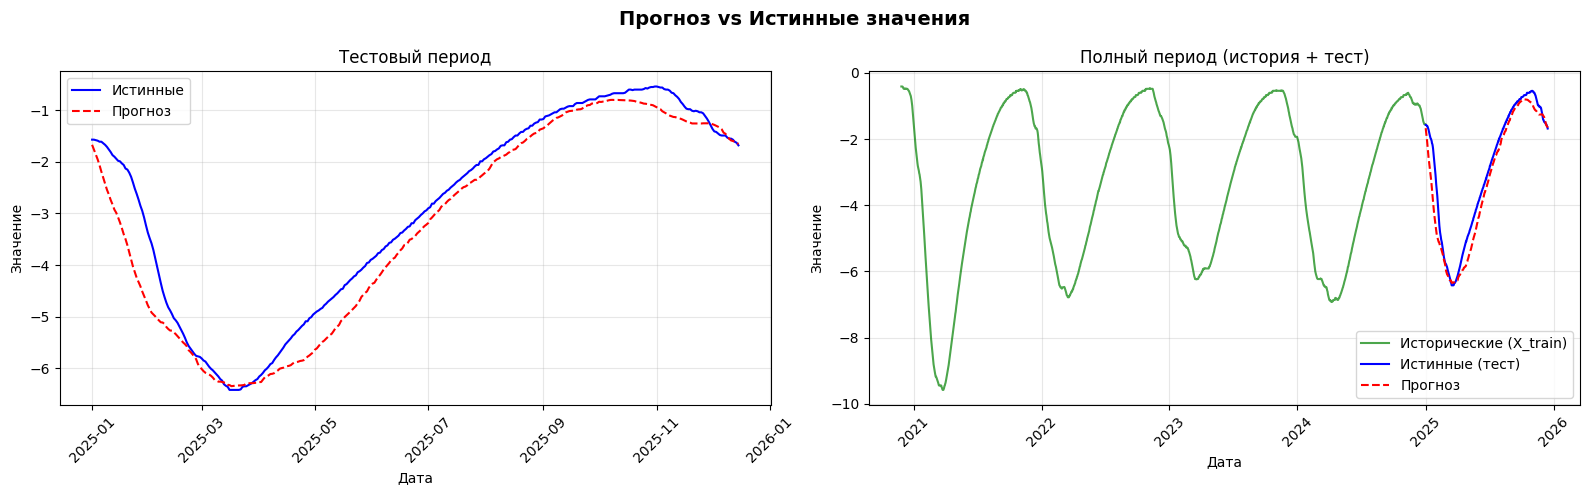

            feature  importance
4    48-1 (5)_lag_2    0.278859
3    48-1 (5)_lag_1    0.254087
2  48-1 (4,5)_lag_1    0.177327
0    48-1 (4)_lag_1    0.165881
1    48-1 (4)_lag_2    0.096435
7   day_of_year_sin    0.014116
5         Месяц_sin    0.011327
9        is_anomaly    0.001001
8   day_of_year_cos    0.000526
6         Месяц_cos    0.000442
48-1 (5)
RMSE на тесте = 0.49180587549441823


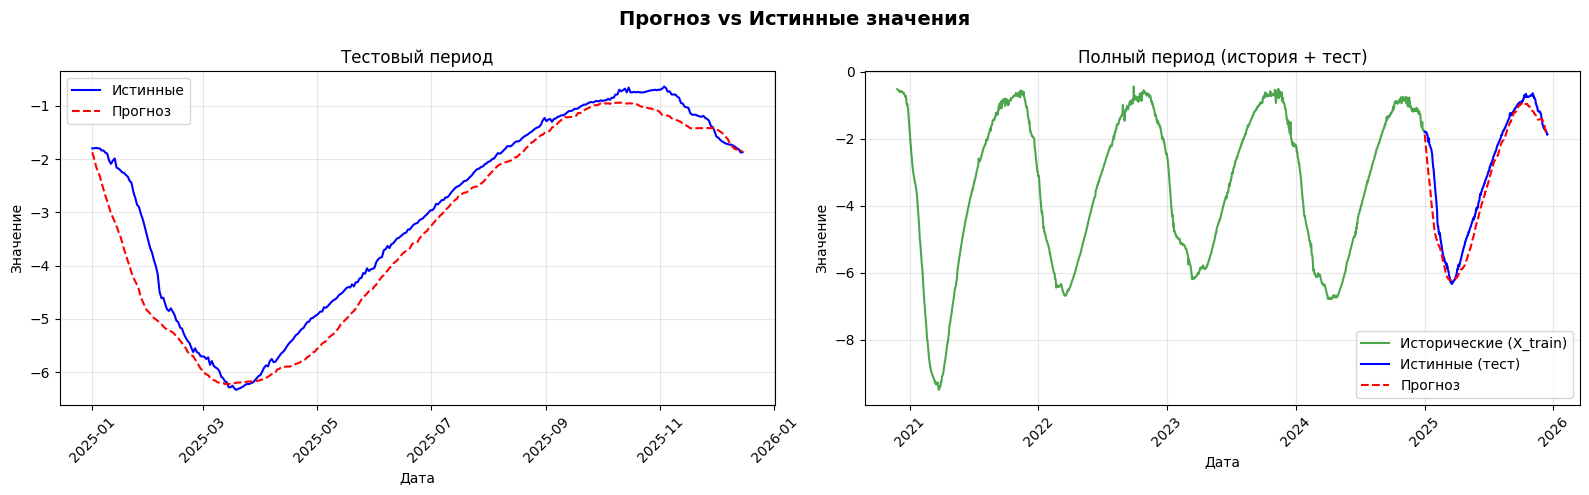

             feature  importance
4     48-1 (6)_lag_1    0.288312
5     48-1 (6)_lag_2    0.198545
2     48-1 (5)_lag_1    0.173430
6     48-1 (6)_lag_3    0.126513
0   48-1 (4,5)_lag_1    0.075144
1   48-1 (4,5)_lag_2    0.071734
3     48-1 (5)_lag_2    0.063376
9    day_of_year_sin    0.001055
11        is_anomaly    0.000631
7          Месяц_sin    0.000500
8          Месяц_cos    0.000395
10   day_of_year_cos    0.000365
48-1 (6)
RMSE на тесте = 0.4689336040076612


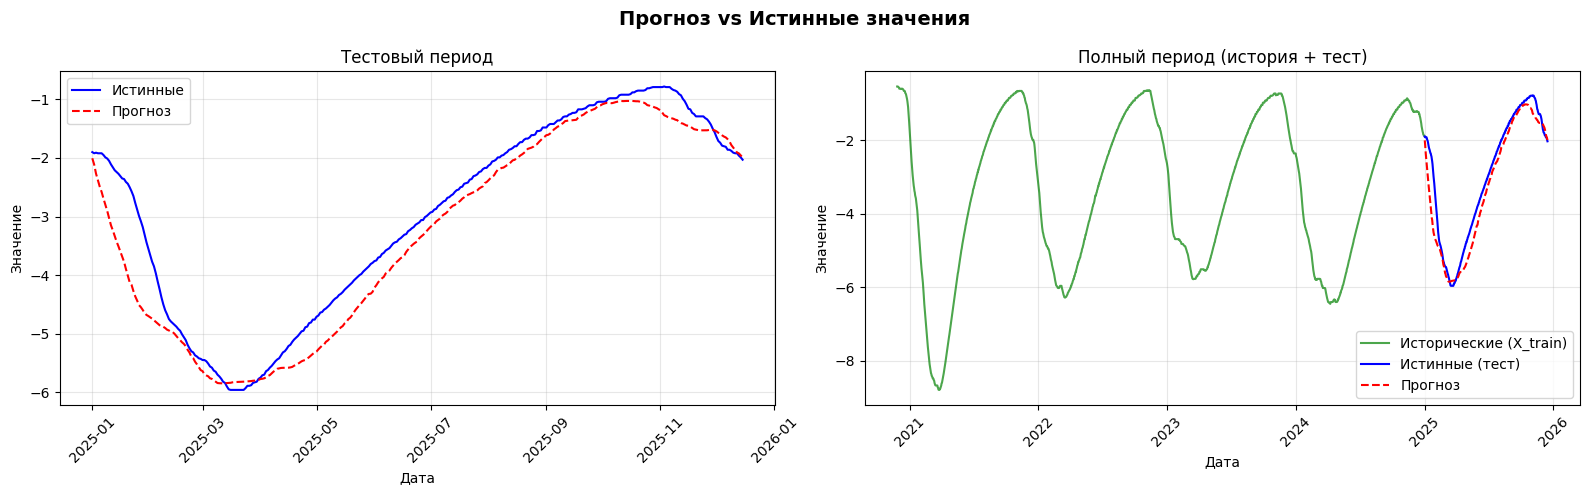

            feature  importance
9    48-1 (7)_lag_2    0.294329
8    48-1 (7)_lag_1    0.227071
3    48-1 (6)_lag_1    0.151084
4    48-1 (6)_lag_2    0.112083
5    48-1 (6)_lag_3    0.075026
0    48-1 (5)_lag_1    0.063141
1    48-1 (5)_lag_2    0.044735
6    48-1 (6)_lag_4    0.021016
2    48-1 (5)_lag_3    0.007956
12  day_of_year_sin    0.001568
14       is_anomaly    0.000666
11        Месяц_cos    0.000423
13  day_of_year_cos    0.000368
10        Месяц_sin    0.000365
7    48-1 (6)_lag_5    0.000169
48-1 (7)
RMSE на тесте = 0.42864161639034903


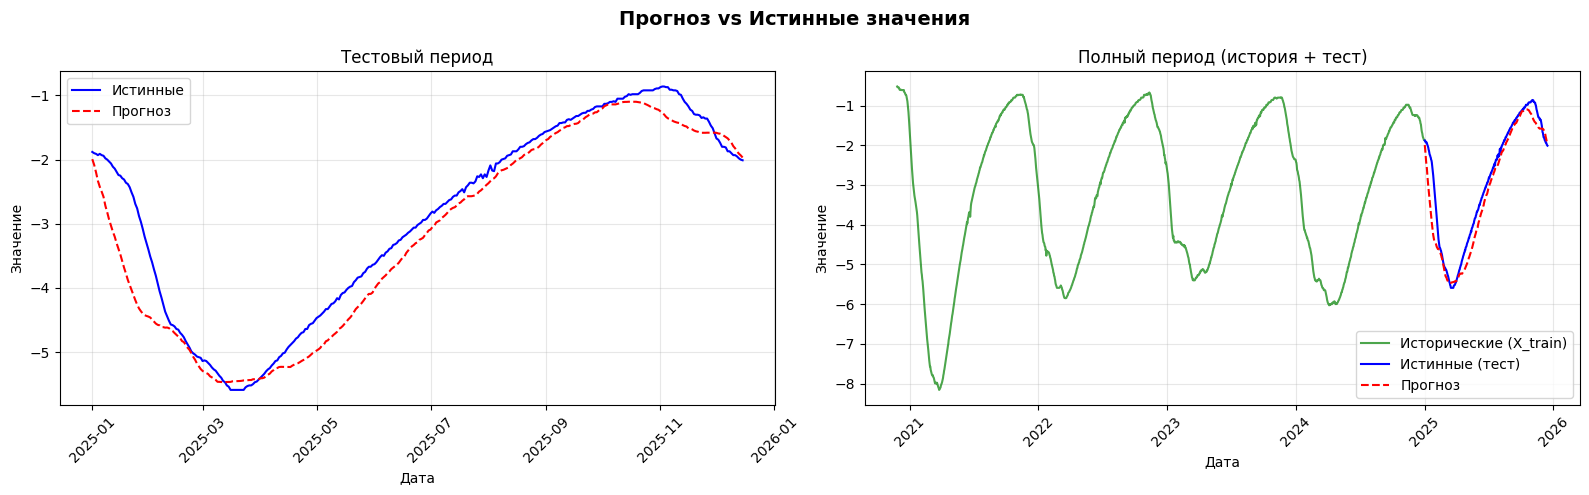

            feature  importance
3    48-1 (7)_lag_1    0.240570
7    48-1 (8)_lag_1    0.187476
0    48-1 (6)_lag_1    0.186650
5    48-1 (7)_lag_3    0.142354
1    48-1 (6)_lag_2    0.120132
4    48-1 (7)_lag_2    0.073072
2    48-1 (6)_lag_3    0.022467
8    48-1 (8)_lag_2    0.013431
6    48-1 (7)_lag_4    0.006952
11  day_of_year_sin    0.004675
13       is_anomaly    0.000822
10        Месяц_cos    0.000608
12  day_of_year_cos    0.000516
9         Месяц_sin    0.000274
48-1 (8)
RMSE на тесте = 0.36955462188680394


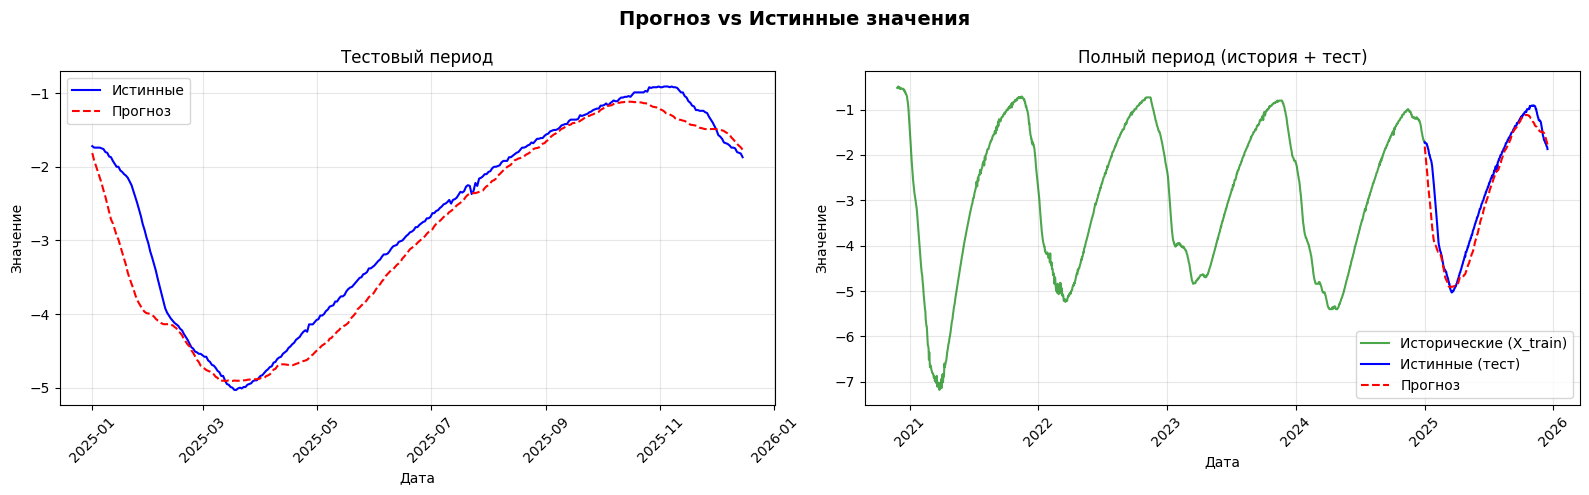

            feature  importance
2    48-1 (8)_lag_2    0.229643
3    48-1 (8)_lag_3    0.185183
1    48-1 (8)_lag_1    0.175902
0    48-1 (7)_lag_1    0.164377
4    48-1 (9)_lag_1    0.116445
5    48-1 (9)_lag_2    0.062193
10       is_anomaly    0.036834
6         Месяц_sin    0.015576
8   day_of_year_sin    0.011950
7         Месяц_cos    0.001218
9   day_of_year_cos    0.000681
48-1 (9)
RMSE на тесте = 0.2707303975658667


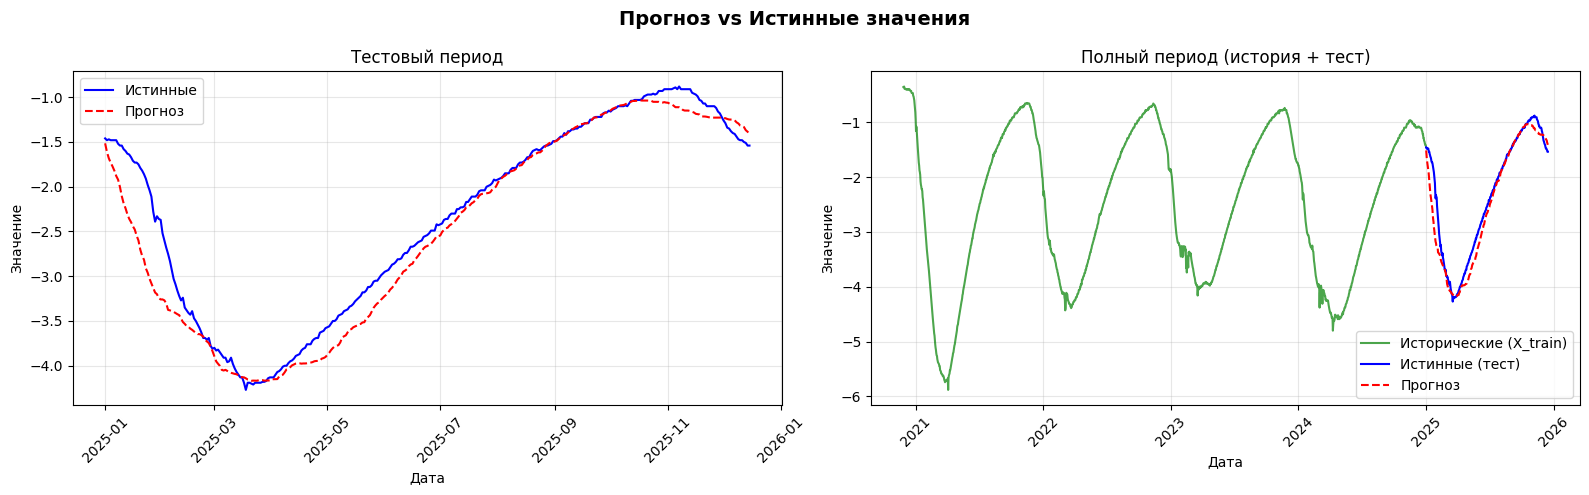

           feature  importance
3        Месяц_sin    0.264490
1   48-1 (9)_lag_1    0.247664
0   48-1 (8)_lag_1    0.169780
5  day_of_year_sin    0.150993
2  48-1 (10)_lag_1    0.104881
7       is_anomaly    0.051744
6  day_of_year_cos    0.007339
4        Месяц_cos    0.003108
48-1 (10)
RMSE на тесте = 0.1721110434206638


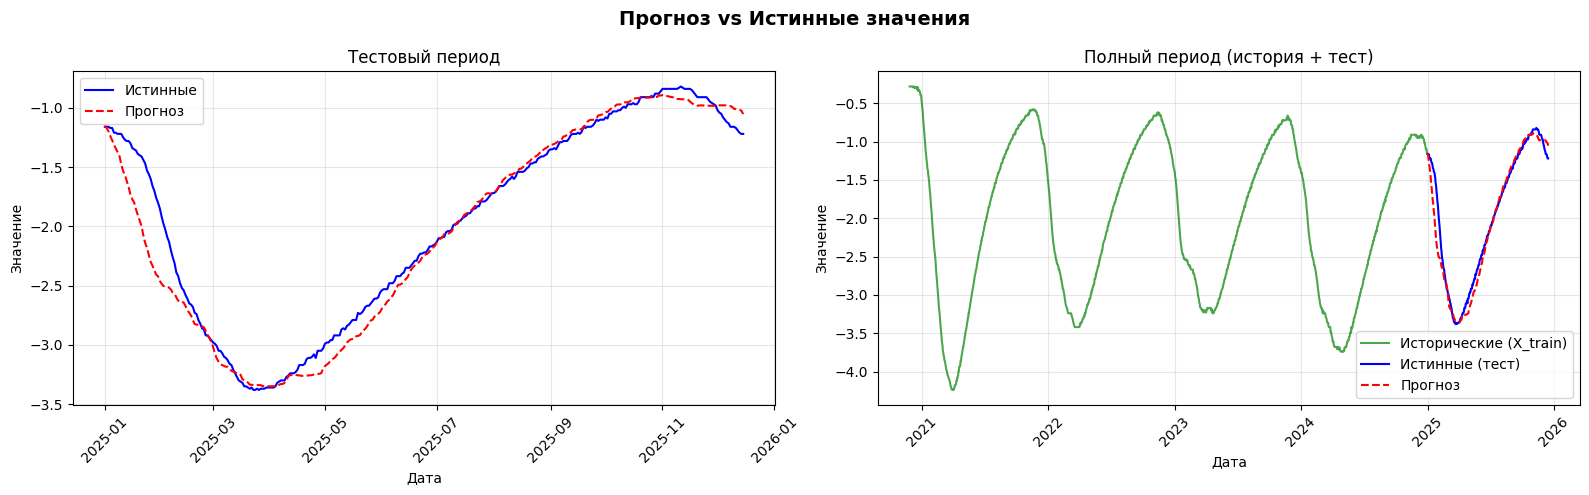

           feature  importance
1   48-1 (9)_lag_2    0.255145
2  48-1 (10)_lag_1    0.230650
0   48-1 (9)_lag_1    0.194665
3        Месяц_sin    0.181820
5  day_of_year_sin    0.088875
7       is_anomaly    0.027367
6  day_of_year_cos    0.011580
4        Месяц_cos    0.009898


In [ ]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast_with_train(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)